# DNN Autoencoder (Baseline model) for Anomaly Detection Using Toy Car Audio

**Purpose:** This notebook presents a complete pipeline for toy car anomaly detection based on operating sound, including data loading, preprocessing, CNN autoencoder training, and result analysis.

## 1. Imports

This notebook is intentionally split into small orchestration steps. Most reusable logic lives in helper modules so future model notebooks can reuse the same data and evaluation pipeline with minimal copy/paste.

In [4]:
import os 
import random

import pickle

import numpy as np

import torch
import torch.nn as nn
from torch.utils.data import Subset, DataLoader

from sklearn.metrics import average_precision_score

import matplotlib.pyplot as plt
import optuna
import optuna.visualization as vis

from helpers.helper_npy_data import (
    UnifiedNPYDataset,
    split_indices,
    compute_target_T_from_npy
)
from helpers.helper_eval import (
    build_scope_loader_dict,
    count_ind_cnt,
    downsample_anomaly_scores,
    evaluate_scores,
    find_best_f1_threshold,
    get_reconstruction_scores,
    infer_case_from_path,
    plot_one_reconstruction,
)

## 2. Paths and configuration

Setting experiment-wide constants here.

In [ ]:
# Paths

DATA_BASE_PATH = "F:ToyCar"

BEST_MODEL_SAVE_PATH = "./outputs/models/best_DNN_AE.pth"

STUDY_SAVE_PATH = './outputs/studies/dnn_study.pkl'

In [12]:
# Configs

CASES = ['case1', 'case2', 'case3', 'case4']
CHANNELS = ['1', '2', '3', '4']
SEED = 42

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cuda


In [14]:
import os

# Updated Paths for the Vast.ai Linux environment
DATA_BASE_PATH = "./data"

# Create the output folders so they exist when PyTorch tries to save
os.makedirs("./outputs/models", exist_ok=True)
os.makedirs("./outputs/studies", exist_ok=True)

BEST_MODEL_SAVE_PATH = "./outputs/models/best_DNN_AE.pth"
STUDY_SAVE_PATH = "./outputs/studies/dnn_study.pkl"

# I'm adding CASES here just in case it wasn't defined earlier in your notebook!
CASES = ["case1", "case2", "case3", "case4"]

## 3. Data Preprocessing

This stage converts raw/precomputed features into model-ready datasets.

Pipeline summary:
1. Get the timeframe (`target_T`) from IND .npy files, it is needed to detect and remove malformed inputs, and also crop CNT samples (if any) into `target_T` length.
2. Build one unified .npy dataset over IND/CNT/anomaly data (loading the .npy from the 01-data preparation step).
3. Split into train/validation/test partitions.

In [15]:
# Estimate a robust common length from IND normal data, then build the unified dataset.
target_T = compute_target_T_from_npy(
    base_path=DATA_BASE_PATH,  # <-- Removed the /npy
    cases=CASES,
)

# Contains all preprocessed .npy 4-channel log-mel spectrogram data
npy_dataset = UnifiedNPYDataset(
    base_path=DATA_BASE_PATH,  # <-- Removed the /npy
    cases=CASES,
    target_T=target_T,
    use_ind=True,
    use_cnt=True,
    include_anomaly=True,
    stride_ratio=3.0,        
)

print(f"Dataset size: {len(npy_dataset)} | target_T: {target_T}")

[INFO] target_T from IND: 582
[INFO] min=582, max=582
[INFO] IND normal: 5400
[INFO] CNT candidates (windows): 15678
[INFO] CNT sampled: 5400
[INFO] IND anomaly: 1058
[WARN] Dropped short samples (< target_T): 1
[INFO] Total samples: 11858
Dataset size: 11858 | target_T: 582


## 4. Dataset Splitting and Loader Setup

This section defines how samples are split and sampled.

Important choices:
- Normal data is split separately for IND and CNT, then merged.
- Anomaly samples are held out for validation/test only.
- Case-aware loaders are prepared to measure both per-case and all-case behavior.

In [16]:
random.seed(42)

# Separate indices
normal_indices = [i for i, (_, _, y) in enumerate(npy_dataset.samples) if y == 0]
anom_indices   = [i for i, (_, _, y) in enumerate(npy_dataset.samples) if y == 1]

# split normal into IND / CNT
ind_indices = [i for i in normal_indices if npy_dataset.samples[i][1] is None]
cnt_indices = [i for i in normal_indices if npy_dataset.samples[i][1] is not None]

random.shuffle(ind_indices)
random.shuffle(cnt_indices)

# Stratified split
ind_train, ind_val, ind_test = split_indices(ind_indices)
cnt_train, cnt_val, cnt_test = split_indices(cnt_indices)

# merge back
train_idx        = ind_train + cnt_train
val_normal_idx   = ind_val + cnt_val
test_normal_idx  = ind_test + cnt_test

# shuffle merged splits
random.shuffle(train_idx)
random.shuffle(val_normal_idx)
random.shuffle(test_normal_idx)

# ANOMALY split (50 / 50)
random.shuffle(anom_indices)

m = len(anom_indices)
val_anom_idx  = anom_indices[:m // 2]
test_anom_idx = anom_indices[m // 2:]

# DATASETS
train_dataset = Subset(npy_dataset, train_idx)

val_normal = Subset(npy_dataset, val_normal_idx)
val_anom   = Subset(npy_dataset, val_anom_idx)

test_normal = Subset(npy_dataset, test_normal_idx)
test_anom   = Subset(npy_dataset, test_anom_idx)

In [17]:
# Distribution check for IND vs CNT samples in each split
train_ind, train_cnt = count_ind_cnt(train_dataset, npy_dataset.samples)
val_ind, val_cnt = count_ind_cnt(val_normal, npy_dataset.samples)
test_ind, test_cnt = count_ind_cnt(test_normal, npy_dataset.samples)

print("Train Normal  -> IND:", train_ind, "CNT:", train_cnt)
print("Val Normal    -> IND:", val_ind, "CNT:", val_cnt)
print("Test Normal   -> IND:", test_ind, "CNT:", test_cnt)
print("Val/Test anomaly sizes:", len(val_anom), len(test_anom)) # Will be further sampled to 5% below

Train Normal  -> IND: 4320 CNT: 4320
Val Normal    -> IND: 540 CNT: 540
Test Normal   -> IND: 540 CNT: 540
Val/Test anomaly sizes: 529 529


In [18]:
# -------------------------
# CASE-AWARE LOADERS
# -------------------------
# Map each sample to its case id to enable case-specific evaluation scopes.
sample_cases = [infer_case_from_path(p) for (p, _, _) in npy_dataset.samples]

VAL_CASE_SCOPES = {
    "case1_only": [CASES[0]],
    "case2_only": [CASES[1]],
    "case3_only": [CASES[2]],
    "case4_only": [CASES[3]],
    "all_cases": CASES,
}

# Training loader uses only normal data.
train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)

val_loaders = build_scope_loader_dict(
    dataset=npy_dataset,
    sample_cases=sample_cases,
    normal_indices=val_normal_idx,
    anom_indices=val_anom_idx,
    case_scopes=VAL_CASE_SCOPES,
    batch_size=8,
    anom_ratio=0.05, 
    prefix="val",
)

for scope_name, data in val_loaders.items():
    print(f"[VAL] {scope_name}: normal={data['n_normal']}, anomaly={data['n_anom']}")

test_loaders = build_scope_loader_dict(
    dataset=npy_dataset,
    sample_cases=sample_cases,
    normal_indices=test_normal_idx,
    anom_indices=test_anom_idx,
    case_scopes=VAL_CASE_SCOPES,
    batch_size=8,
    anom_ratio=0.05, 
    prefix="test",
)

for scope_name, data in test_loaders.items():
    print(f"[TEST] {scope_name}: normal={data['n_normal']}, anomaly={data['n_anom']}")

val_normal_loader = val_loaders["all_cases"]["val_normal_loader"]
val_anom_loader = val_loaders["all_cases"]["val_anom_loader"]
test_normal_loader = test_loaders["all_cases"]["test_normal_loader"]
test_anom_loader = test_loaders["all_cases"]["test_anom_loader"]

[VAL] case1_only: normal=124, anomaly=6
[VAL] case2_only: normal=144, anomaly=7
[VAL] case3_only: normal=145, anomaly=7
[VAL] case4_only: normal=127, anomaly=6
[VAL] all_cases: normal=540, anomaly=27
[TEST] case1_only: normal=145, anomaly=7
[TEST] case2_only: normal=142, anomaly=7
[TEST] case3_only: normal=123, anomaly=6
[TEST] case4_only: normal=130, anomaly=6
[TEST] all_cases: normal=540, anomaly=27


## 5. Model

The architecture is a Transformer AutoEncoder over time patches of log-mel tensors.

Intuition:
- Patch tokens reduce sequence length and memory usage.
- Encoder learns compact temporal representations.
- Decoder reconstructs inputs; reconstruction error acts as anomaly score.

In [19]:
class DNN_AutoEncoder(nn.Module):
    def __init__(self, hidden_dims, latent_dim, input_shape, dropout=0.0):
        super().__init__()

        self.input_shape = input_shape
        self.input_dim = int(torch.prod(torch.tensor(input_shape)))

        # Encoder (MLP)
        encoder = []
        in_dim = self.input_dim

        for h in hidden_dims:
            encoder.append(nn.Linear(in_dim, h))
            encoder.append(nn.ReLU())

            if dropout > 0:
                encoder.append(nn.Dropout(dropout))

            in_dim = h

        self.encoder = nn.Sequential(*encoder)

        # Bottleneck
        self.fc_enc = nn.Linear(in_dim, latent_dim)
        self.fc_dec = nn.Linear(latent_dim, in_dim)

        self.dropout_fc = nn.Dropout(dropout) if dropout > 0 else nn.Identity()

        # Decoder (MLP)
        decoder = []
        in_dim = hidden_dims[-1] if hidden_dims else self.input_dim

        for h in reversed(hidden_dims[:-1]):
            decoder.append(nn.Linear(in_dim, h))
            decoder.append(nn.ReLU())

            if dropout > 0:
                decoder.append(nn.Dropout(dropout))

            in_dim = h

        decoder.append(nn.Linear(in_dim, self.input_dim))

        self.decoder = nn.Sequential(*decoder)

    def forward(self, x):
        B = x.size(0)

        # Flatten
        x_flat = x.view(B, -1)

        # Encode
        z = self.encoder(x_flat)

        z = self.fc_enc(z)
        z = self.dropout_fc(z)

        # Decode
        z = self.fc_dec(z)

        out = self.decoder(z)

        # Reshape back
        out = out.view(B, *self.input_shape)

        return out

## 6. Fine Tuning

Optuna searches model and training hyperparameters.

Each trial trains a candidate model and reports validation PR-AUC on the selected tuning scope.

In [20]:
# Hyperparameter search controls
TUNE_SCOPE = "all_cases"
N_TRIALS = 5
TUNE_EPOCHS = 5


def objective(trial):
    print(f"\n=== Trial {trial.number} ===")

    # DNN parameters
    depth = trial.suggest_int("depth", 2, 4)

    base_dim = trial.suggest_categorical("base_dim", [256, 512, 1024])

    # build hidden dims (decreasing)
    hidden_dims = [base_dim // (2**i) for i in range(depth)]

    latent_dim = trial.suggest_categorical("latent_dim", [8, 16, 32])

    # Training params
    lr = trial.suggest_float("lr", 1e-4, 3e-3, log=True)
    weight_decay = trial.suggest_float("weight_decay", 1e-7, 1e-3, log=True)
    dropout = trial.suggest_float("dropout", 0.0, 0.3)

    batch_size = trial.suggest_categorical("batch_size", [8, 16, 32])
    noise_std = trial.suggest_float("noise_std", 0.0, 0.05)

    score_type = trial.suggest_categorical("score_type", ["l1", "l2"])

    # Data
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

    sample_x, _ = next(iter(train_loader))
    input_shape = sample_x.shape[1:]

    # Model
    model = DNN_AutoEncoder(
        hidden_dims=hidden_dims,
        latent_dim=latent_dim,
        input_shape=input_shape,
        dropout=dropout
    ).to(device)

    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)

    criterion = nn.L1Loss() if score_type == "l1" else nn.MSELoss()

    # Helper
    def compute_pr_auc(vn_loader, va_loader):
        normal_scores = get_reconstruction_scores(model, vn_loader, device, score_type=score_type)
        anom_scores   = get_reconstruction_scores(model, va_loader, device, score_type=score_type)

        y_true = np.concatenate([
            np.zeros(len(normal_scores)),
            np.ones(len(anom_scores))
        ])
        y_score = np.concatenate([normal_scores, anom_scores])

        if len(np.unique(y_true)) < 2:
            return 0.5, normal_scores, anom_scores

        return average_precision_score(y_true, y_score), normal_scores, anom_scores

    # Train
    for epoch in range(TUNE_EPOCHS):
        model.train()
        total_loss = 0

        for x, _ in train_loader:
            x = x.to(device)

            # denoising
            x_noisy = x + noise_std * torch.randn_like(x) if noise_std > 0 else x

            recon = model(x_noisy)
            loss = criterion(recon, x)

            optimizer.zero_grad()
            loss.backward()

            optimizer.step()
            total_loss += loss.item()

        # Validation during training
        if epoch % 5 == 0:
            vn_loader = val_loaders[TUNE_SCOPE]["val_normal_loader"]
            va_loader = val_loaders[TUNE_SCOPE]["val_anom_loader"]

            pr_auc, _, _ = compute_pr_auc(vn_loader, va_loader)

            if epoch >= 10:
                trial.report(pr_auc, epoch)
                if trial.should_prune():
                    raise optuna.TrialPruned()

    # Final validation
    results = {}

    for scope_name, loaders in val_loaders.items():
        vn_loader = loaders["val_normal_loader"]
        va_loader = loaders["val_anom_loader"]

        pr_auc, normal_scores, anom_scores = compute_pr_auc(vn_loader, va_loader)

        results[scope_name] = pr_auc
        trial.set_user_attr(f"{scope_name}_pr_auc", float(pr_auc))

        if scope_name == TUNE_SCOPE:
            gap = float(np.mean(anom_scores) - np.mean(normal_scores))
            trial.set_user_attr("gap", gap)

    print("Validation PR AUC:")
    for k, v in results.items():
        print(f"  {k}: {v:.4f}")

    return float(results[TUNE_SCOPE])

In [21]:
# Enable concise Optuna logs plus a custom callback for per-trial summaries.
optuna.logging.set_verbosity(optuna.logging.INFO)
def print_callback(study, trial):
    print(f"\nTrial {trial.number} finished")
    if trial.value is None:
        print("[ERROR] Failed!")
    else:
        print(f"  Value: {trial.value:.4f}")
    print(f"  Params: {trial.params}")

study = optuna.create_study(direction="maximize")

study.optimize(objective, n_trials=N_TRIALS, callbacks=[print_callback])

for t in study.trials:
    print_callback(study, t)

print("[BEST] AUC:", study.best_value)
print("[BEST] params:", study.best_params)
print("[BEST] gap:", study.best_trial.user_attrs.get("gap", None))

[I 2026-04-18 16:11:20,807] A new study created in memory with name: no-name-c34b6b14-7758-4224-a33d-63419a823bda



=== Trial 0 ===


[I 2026-04-18 16:12:52,294] Trial 0 finished with value: 0.6938541691843096 and parameters: {'depth': 4, 'base_dim': 1024, 'latent_dim': 16, 'lr': 0.0002899780181151795, 'weight_decay': 1.0599164495801379e-07, 'dropout': 0.053058843409081576, 'batch_size': 16, 'noise_std': 0.025010785097255846, 'score_type': 'l2'}. Best is trial 0 with value: 0.6938541691843096.


Validation PR AUC:
  case1_only: 0.4257
  case2_only: 0.8866
  case3_only: 1.0000
  case4_only: 1.0000
  all_cases: 0.6939

Trial 0 finished
  Value: 0.6939
  Params: {'depth': 4, 'base_dim': 1024, 'latent_dim': 16, 'lr': 0.0002899780181151795, 'weight_decay': 1.0599164495801379e-07, 'dropout': 0.053058843409081576, 'batch_size': 16, 'noise_std': 0.025010785097255846, 'score_type': 'l2'}

=== Trial 1 ===


[I 2026-04-18 16:14:15,491] Trial 1 finished with value: 0.2850684755141802 and parameters: {'depth': 4, 'base_dim': 1024, 'latent_dim': 32, 'lr': 0.00016667004504983032, 'weight_decay': 1.6099829315782753e-05, 'dropout': 0.18145422684926296, 'batch_size': 16, 'noise_std': 0.004770522697962409, 'score_type': 'l2'}. Best is trial 0 with value: 0.6938541691843096.


...

Validation PR AUC:
  case1_only: 0.2257
  case2_only: 0.8442
  case3_only: 0.0973
  case4_only: 0.8182
  all_cases: 0.1338

Trial 2 finished
  Value: 0.1338
  Params: {'depth': 3, 'base_dim': 1024, 'latent_dim': 8, 'lr': 0.0013651933671070475, 'weight_decay': 8.338653088880743e-05, 'dropout': 0.009453579239751908, 'batch_size': 16, 'noise_std': 0.028284361548967737, 'score_type': 'l1'}

=== Trial 3 ===


[I 2026-04-18 16:18:06,098] Trial 3 finished with value: 0.1657139289826624 and parameters: {'depth': 4, 'base_dim': 512, 'latent_dim': 16, 'lr': 0.0011814496624351386, 'weight_decay': 1.1398743737536184e-05, 'dropout': 0.16497614193087176, 'batch_size': 8, 'noise_std': 0.00029811630653147627, 'score_type': 'l1'}. Best is trial 0 with value: 0.6938541691843096.


Validation PR AUC:
  case1_only: 0.2798
  case2_only: 0.8244
  case3_only: 0.2851
  case4_only: 0.8542
  all_cases: 0.1657

Trial 3 finished
  Value: 0.1657
  Params: {'depth': 4, 'base_dim': 512, 'latent_dim': 16, 'lr': 0.0011814496624351386, 'weight_decay': 1.1398743737536184e-05, 'dropout': 0.16497614193087176, 'batch_size': 8, 'noise_std': 0.00029811630653147627, 'score_type': 'l1'}

=== Trial 4 ===


[I 2026-04-18 16:19:30,389] Trial 4 finished with value: 0.5770243137145921 and parameters: {'depth': 4, 'base_dim': 1024, 'latent_dim': 16, 'lr': 0.00015707358238917219, 'weight_decay': 3.4440403455903826e-07, 'dropout': 0.06996212235814452, 'batch_size': 16, 'noise_std': 0.03911187221967552, 'score_type': 'l1'}. Best is trial 0 with value: 0.6938541691843096.


Validation PR AUC:
  case1_only: 0.3431
  case2_only: 0.9098
  case3_only: 1.0000
  case4_only: 0.9242
  all_cases: 0.5770

Trial 4 finished
  Value: 0.5770
  Params: {'depth': 4, 'base_dim': 1024, 'latent_dim': 16, 'lr': 0.00015707358238917219, 'weight_decay': 3.4440403455903826e-07, 'dropout': 0.06996212235814452, 'batch_size': 16, 'noise_std': 0.03911187221967552, 'score_type': 'l1'}

Trial 0 finished
  Value: 0.6939
  Params: {'depth': 4, 'base_dim': 1024, 'latent_dim': 16, 'lr': 0.0002899780181151795, 'weight_decay': 1.0599164495801379e-07, 'dropout': 0.053058843409081576, 'batch_size': 16, 'noise_std': 0.025010785097255846, 'score_type': 'l2'}

Trial 1 finished
  Value: 0.2851
  Params: {'depth': 4, 'base_dim': 1024, 'latent_dim': 32, 'lr': 0.00016667004504983032, 'weight_decay': 1.6099829315782753e-05, 'dropout': 0.18145422684926296, 'batch_size': 16, 'noise_std': 0.004770522697962409, 'score_type': 'l2'}

Trial 2 finished
  Value: 0.1338
  Params: {'depth': 3, 'base_dim': 1024,

In [22]:
# Save study into Pickle .pkl file
with open(STUDY_SAVE_PATH, "wb") as f:
    pickle.dump(study, f)

In [24]:

# ================================
# Optimization History
# ================================
# Shows how the objective value (PR-AUC) evolves over trials.
# Useful for checking:
# - whether the search is converging
# - whether more trials are needed
# - stability of the optimization process
vis.plot_optimization_history(study).show()


# ================================
# Hyperparameter Importance
# ================================
# Ranks hyperparameters based on their impact on the objective.
# Useful for:
# - identifying which parameters matter most (e.g., lr, latent_dim)
# - pruning irrelevant parts of the search space
vis.plot_param_importances(study).show()


/tmp/ipykernel_2248/3877234270.py:5: ExperimentalWarning: optuna.visualization.matplotlib._optimization_history.plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  vis_mpl.plot_optimization_history(study)


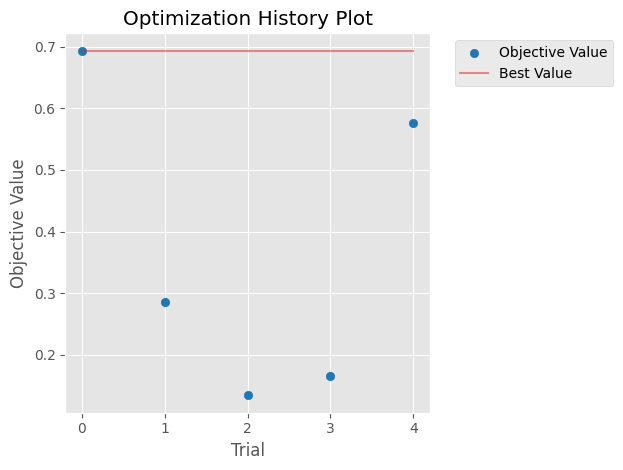

/tmp/ipykernel_2248/3877234270.py:9: ExperimentalWarning: optuna.visualization.matplotlib._param_importances.plot_param_importances is experimental (supported from v2.2.0). The interface can change in the future.
  vis_mpl.plot_param_importances(study)


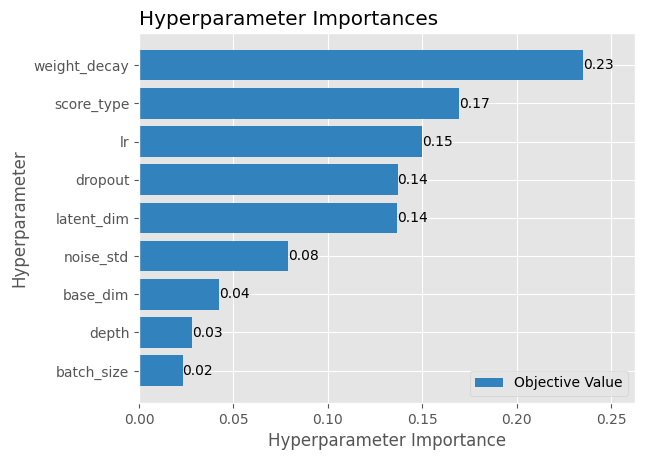

In [26]:
import optuna.visualization.matplotlib as vis_mpl
import matplotlib.pyplot as plt

# Plot optimization history
vis_mpl.plot_optimization_history(study)
plt.show()

# Plot parameter importances
vis_mpl.plot_param_importances(study)
plt.show()

In [27]:
print(study.best_params)

{'depth': 4, 'base_dim': 1024, 'latent_dim': 16, 'lr': 0.0002899780181151795, 'weight_decay': 1.0599164495801379e-07, 'dropout': 0.053058843409081576, 'batch_size': 16, 'noise_std': 0.025010785097255846, 'score_type': 'l2'}


## 7. Training the model using the optimal hyperparams

In [28]:
# Rebuild model with best params

best_params = study.best_params
depth = best_params["depth"]

# changed "base_channels" to "base_dim" to match Optuna!
base_channels = best_params["base_dim"] 

channels = [base_channels * (2**i) for i in range(depth)]
latent_dim = best_params["latent_dim"]
dropout = best_params['dropout']
    
sample_x, _ = next(iter(train_loader))
input_shape = sample_x.shape[1:]

model = DNN_AutoEncoder(channels, latent_dim, input_shape, dropout).to(device)

In [29]:
# Train final model using best trial hyperparameters.
# This stage creates the checkpoint used for downstream evaluation.
train_loader = DataLoader(train_dataset, batch_size=best_params["batch_size"], shuffle=True)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=best_params["lr"],
    weight_decay=best_params["weight_decay"]
)

criterion = nn.L1Loss()
train_loss_hist = []
val_loss_hist = []

for epoch in range(TUNE_EPOCHS):
    model.train()
    train_loss = 0

    for x, _ in train_loader:
        x = x.to(device)

        if best_params["noise_std"] > 0:
            x_noisy = x + best_params["noise_std"] * torch.randn_like(x)
        else:
            x_noisy = x

        recon = model(x_noisy)
        loss = criterion(recon, x)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    train_loss /= len(train_loader)
    train_loss_hist.append(train_loss)

    model.eval()
    val_loss = 0

    with torch.no_grad():
        for x, _ in val_normal_loader:
            x = x.to(device)
            recon = model(x)
            val_loss += criterion(recon, x).item()

    val_loss /= len(val_normal_loader)
    val_loss_hist.append(val_loss)

    print(f"Epoch {epoch+1}: Train={train_loss:.4f}, Val={val_loss:.4f}")

torch.save(model.state_dict(), BEST_MODEL_SAVE_PATH)

Epoch 1: Train=0.0964, Val=0.0505
Epoch 2: Train=0.0577, Val=0.0536
Epoch 3: Train=0.0554, Val=0.0515
Epoch 4: Train=0.0547, Val=0.0641
Epoch 5: Train=0.0529, Val=0.0478


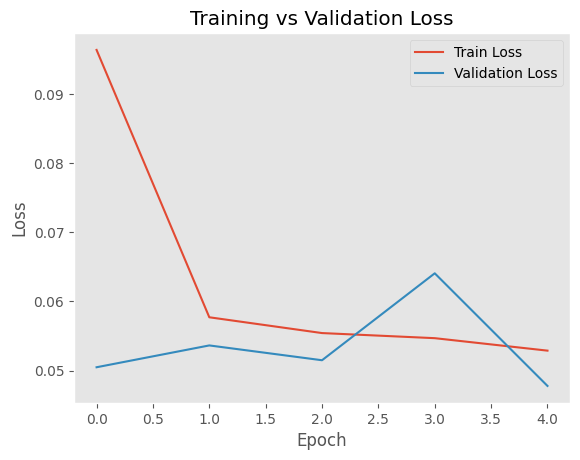

In [30]:
plt.figure()
plt.plot(train_loss_hist, label="Train Loss")
plt.plot(val_loss_hist, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid()
plt.show()

## 8. Model Evaluation

Evaluation is performed in two steps:
1. Find a threshold on validation scores (best F1).
2. Report PR-AUC/F1/gap on overall and per-case test sets.

In [ ]:
# Optional: Load saved model

# with open(STUDY_SAVE_PATH, 'rb') as f:
#     study = pickle.load(f)

# best_params = study.best_params
# depth = best_params["depth"]
# base_channels = best_params["base_channels"]
# channels = [base_channels * (2**i) for i in range(depth)]
# latent_dim = best_params["latent_dim"]
# dropout = best_params['dropout']

# sample_x, _ = next(iter(train_loader))
# input_shape = sample_x.shape[1:]

# model = DNN_AutoEncoder(channels, latent_dim, input_shape, dropout).to(device)
# model.load_state_dict(torch.load(BEST_MODEL_SAVE_PATH, map_location=device))
# model.eval()

In [31]:
# Compute validation threshold by maximizing F1 on validation scores.
# This converts continuous anomaly scores into a binary decision boundary.
val_normal_scores = get_reconstruction_scores(
    model,
    val_normal_loader,
    device,
    score_type=best_params["score_type"],
)
val_anom_scores = get_reconstruction_scores(
    model,
    val_anom_loader,
    device,
    score_type=best_params["score_type"],
)

best_threshold = find_best_f1_threshold(val_normal_scores, val_anom_scores)
print("Best threshold:", best_threshold)

Best threshold: 0.004541180562227964


In [32]:
# Evaluate on the overall test scope (`all_cases`).
# Keep anomaly ratio aligned with validation for fair comparison.
test_normal_scores = get_reconstruction_scores(
    model,
    test_normal_loader,
    device,
    score_type=best_params["score_type"],
)
test_anom_scores = get_reconstruction_scores(
    model,
    test_anom_loader,
    device,
    score_type=best_params["score_type"],
)

pr_auc, f1, gap = evaluate_scores(test_normal_scores, test_anom_scores, best_threshold)

print("Best threshold:", best_threshold)
print("Test PR-AUC:", pr_auc)
print("Test F1:", f1)
print("Normal Mean Error:", float(np.mean(test_normal_scores)))
print("Anomalous Mean Error:", float(np.mean(test_anom_scores)))
print("Error Gap:", gap)

Best threshold: 0.004541180562227964
Test PR-AUC: 0.6205739384816665
Test F1: 0.7076923076923077
Normal Mean Error: 0.003995581064373255
Anomalous Mean Error: 0.0054734074510633945
Error Gap: 0.0014778263866901398


In [33]:
# Per-case test results highlight whether performance is consistent across cases.
print("\n=== Per-case Test Results ===")

all_normal_scores = []
all_anom_scores = []

for scope_name, loaders in test_loaders.items():
    normal_scores = get_reconstruction_scores(
        model,
        loaders["test_normal_loader"],
        device,
        score_type=best_params["score_type"],
    )
    anom_scores = get_reconstruction_scores(
        model,
        loaders["test_anom_loader"],
        device,
        score_type=best_params["score_type"],
    )

    # Use full anomaly set per case for stable per-case reporting.
    anom_scores = downsample_anomaly_scores(normal_scores, anom_scores, anom_ratio=1.0)

    if scope_name != "all_cases":
        all_normal_scores.extend(normal_scores)
        all_anom_scores.extend(anom_scores)

    pr_auc, f1, gap = evaluate_scores(normal_scores, anom_scores, best_threshold)
    print(f"{scope_name}: PR-AUC={pr_auc:.4f}, F1={f1:.4f}, Gap={gap:.4f}")


=== Per-case Test Results ===
case1_only: PR-AUC=0.7456, F1=0.6364, Gap=0.0097
case2_only: PR-AUC=0.7377, F1=0.6000, Gap=0.0008
case3_only: PR-AUC=0.6079, F1=0.6667, Gap=0.0117
case4_only: PR-AUC=0.9762, F1=0.8333, Gap=0.0014
all_cases: PR-AUC=0.6206, F1=0.7077, Gap=0.0015


## 9. Result visualization

Qualitative plots are useful to confirm whether anomalies produce larger localized reconstruction errors than normal samples.

In [ ]:
# Visual check on one normal sample.
test_normal_iter = iter(test_normal_loader)
plot_one_reconstruction(model, test_normal_iter, device)

In [ ]:
# Visual check on one anomaly sample.
test_anom_iter = iter(test_anom_loader)
plot_one_reconstruction(model, test_anom_iter, device)